# Final results: judges × KB

Tables and figures of the paper's *Results* section, over the judges in `USE_JUDGES` and both KBs:
§1 judges and ground truth, §2 nDCG@10, §3 rank change.

Reads `datasets/findhr/final/*.csv`, written by `evaluation_all_judges.py`, and each judge's
`gt_pairs.csv`. Writes the tables to `final/tables/` and the figures to `final/imgs/`.

In [1]:
import sys; sys.path.append("../..")
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Patch
from scipy.stats import kendalltau
from sklearn.metrics import cohen_kappa_score, confusion_matrix

from pipeline.utils.ranking_utils import (
    ARM_ORDER, FAMILY_LABELS, FULL_ARMS, JUDGES, KBS, KB_METHODS, kb_arms,
)
from pipeline.utils.result_utils import float_table, mark, nz, render, style
from pipeline.utils.paper_style import FAMILY_COLORS, figsize, paper_ax, solid, trim_zero

DATA_DIR = Path("../../datasets/findhr")
FINAL = DATA_DIR / "final"
TAB_DIR, IMG_DIR = FINAL / "tables", FINAL / "imgs"

GRADES = np.array([0, 1, 2])
ALPHA = 0.05
BASELINE = "B_only"
REF = "qwen3-8b"                                   # the judge of the paper's main tables, in bold
KB_TITLE = {"esco": "ESCO", "onet": "O*NET"}
KEY = ["id_j", "id_c"]
# The judges this notebook reports, in the order of tables and figures: any subset of ranking_utils.JUDGES
# holding REF. Tables, figures, means and sd are all over these judges only.
USE_JUDGES = ["qwen3-8b", "qwen3-14b", "ministral-3-14b"]
JUDGES = {j: JUDGES[j] for j in USE_JUDGES}
assert REF in JUDGES, f"{REF}, the judge of the main tables, must be in USE_JUDGES"
PAIRS = list(combinations(JUDGES, 2))              # every pair of judges

# Per family: its macro in the paper, and the two descriptive columns of tab:arm-summary.
FAM_TEX = {"B_only": r"$\bn$", "Placebo": r"$\pl$", "SY_raw": r"$\rw$", "SY": r"$\sy$",
           "KB_neighbor": r"$\tne$", "KB_hop": r"$\thop$", "Transformer": r"$\tfe$",
           "Transformer_raw": r"$\tfr$"}
META = {"B_only": ("--", "--"), "Placebo": (r"\yes", "perm."), "SY_raw": (r"\no", r"$\ind$"),
        "SY": (r"\yes", r"$\ind$"), "KB_neighbor": (r"\yes", r"$\sne$"),
        "KB_hop": (r"\yes", r"$\shop$"), "Transformer": (r"\yes", "cos"),
        "Transformer_raw": (r"\no", "cos")}
# Figures: each panel names its KB, so label and color depend on the family only.
LABEL, COLOR = FAMILY_LABELS, FAMILY_COLORS
# The 12-row tables: the KB-free controls, ESCO, O*NET, then T_TF^(r), ruled apart.
BLOCKS = ([ARM_ORDER[:3]] + [[f"{f}_{kb}" for f in ARM_ORDER if f in KB_METHODS] for kb in KBS]
          + [ARM_ORDER[-1:]])
assert sum(BLOCKS, []) == FULL_ARMS


def arm_of(fam, kb):
    return f"{fam}_{kb}" if fam in KB_METHODS else fam


def need(path):
    if not path.exists():
        raise FileNotFoundError(f"{path} not found: run pipeline/4_evaluation/evaluation_all_judges.py first")
    return path


def f3(v):
    return nz(f"{v:.3f}")


def pm(values, best=False, dec=3):
    r"""`$.538 \pm .021$`: mean and sd (ddof=1) over the judges; the mean in bold when `best`."""
    m, s = nz(f"{np.mean(values):.{dec}f}"), nz(f"{np.std(values, ddof=1):.{dec}f}")
    m = rf"\mathbf{{{m}}}" if best else m
    return rf"${m} \pm {s}$"


def save_tex(name, tex):
    """Render the LaTeX inline (or print it) and write it to final/tables/<name>.tex."""
    render(tex)
    (TAB_DIR / f"{name}.tex").write_text(tex + "\n")


In [2]:
summary = pd.read_csv(need(FINAL / "arm_summary.csv"))
summary = summary[summary.judge.isin(JUDGES)]
pairwise = pd.read_csv(need(FINAL / "pairwise_pvalues.csv"))
pairwise = pairwise[pairwise.judge.isin(JUDGES)]
src = pd.read_csv(need(FINAL / "src_summary.csv"))
src = src[src.judge.isin(JUDGES)]
gt = {j: pd.read_csv(need(DATA_DIR / "judges" / j / "results/gt_pairs.csv")).sort_values(KEY).reset_index(drop=True)
      for j in JUDGES}
TAB_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

n_pairs = len(FULL_ARMS) * (len(FULL_ARMS) - 1) // 2
assert set(summary.judge) == set(JUDGES), set(summary.judge)
assert all(len(g) == len(FULL_ARMS) and set(g.arm) == set(FULL_ARMS) for _, g in summary.groupby("judge"))
assert set(pairwise.judge) == set(JUDGES) and pairwise.groupby("judge").size().eq(n_pairs).all()
assert src.groupby("judge").size().eq((len(FULL_ARMS) - 1) * len(GRADES)).all()
ref_keys = gt[REF][KEY]
assert len(ref_keys) == 19_116 and all(g[KEY].equals(ref_keys) for g in gt.values()), "judges labelled different pairs"

S = summary.set_index(["judge", "arm"])
SRC = src.set_index(["judge", "arm", "grade"]).sort_index()
summary.pivot(index="arm", columns="judge", values="ndcg_mean").loc[FULL_ARMS, list(JUDGES)].round(3)


judge,qwen3-8b,qwen3-14b,ministral-3-14b
arm,,,
B_only,0.275,0.318,0.245
Placebo,0.248,0.306,0.219
SY_raw,0.432,0.505,0.412
SY_esco,0.538,0.618,0.513
KB_neighbor_esco,0.577,0.645,0.559
KB_hop_esco,0.593,0.660,0.563
Transformer_esco,0.626,0.694,0.603
SY_onet,0.498,0.568,0.488
KB_neighbor_onet,0.548,0.613,0.520


## 1. Judges and ground truth

*Label distribution, self-consistency and agreement between judges (paper: Applications and Relevance Judgment).*


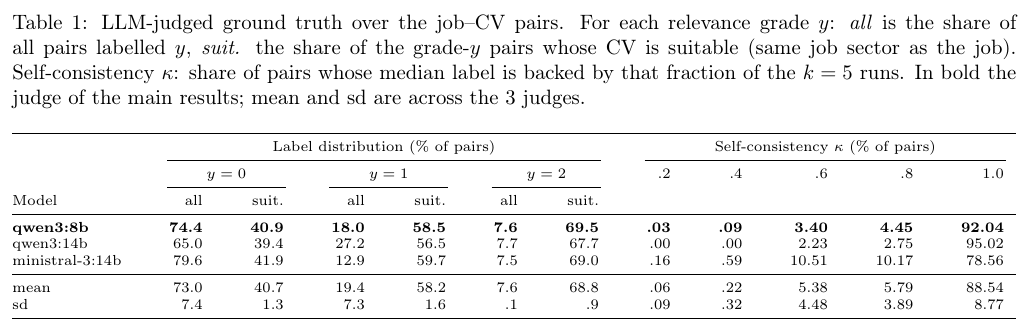

In [3]:
# Per grade: the share of all pairs, and the share of the grade's pairs that are suitable;
# then the self-consistency profile (share of pairs at each confidence level).
ALPHAS = [0.2, 0.4, 0.6, 0.8, 1.0]
DEC = [1] * (2 * len(GRADES)) + [2] * len(ALPHAS)      # decimals, column by column
fmt = lambda x, d: f"{x:.{d}f}".lstrip("0")            # .03, not 0.03, as in the paper


def judge_vals(j):
    g = gt[j]
    pool = g.grade.value_counts(normalize=True) * 100
    suit = g.groupby("grade").category_match.mean() * 100
    conf = g.confidence.value_counts(normalize=True) * 100
    return ([x for k in GRADES for x in (pool.get(k, 0), suit.get(k, 0))]
            + [conf.get(a, 0) for a in ALPHAS])


M = np.array([judge_vals(j) for j in JUDGES])
body = [" & ".join(rf"\textbf{{{x}}}" if j == REF else x
                   for x in [JUDGES[j]] + [fmt(v, d) for v, d in zip(M[i], DEC)]) + r" \\"
        for i, j in enumerate(JUDGES)]
body += [r"\midrule",
         " & ".join(["mean"] + [fmt(m, d) for m, d in zip(M.mean(axis=0), DEC)]) + r" \\",
         " & ".join(["sd"] + [fmt(s, d) for s, d in zip(M.std(axis=0, ddof=1), DEC)]) + r" \\"]
head = [r"& \multicolumn{6}{c}{Label distribution (\% of pairs)} & \multicolumn{5}{c}{Self-consistency $\kappa$ (\% of pairs)} \\",
        r"\cmidrule(lr){2-7}\cmidrule(lr){8-12}",
        r"& \multicolumn{2}{c}{$y=0$} & \multicolumn{2}{c}{$y=1$} & \multicolumn{2}{c}{$y=2$} & $.2$ & $.4$ & $.6$ & $.8$ & $1.0$ \\",
        r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}",
        r"Model & all & suit. & all & suit. & all & suit. & & & & & \\"]
save_tex("judge_labels", float_table(
    r"LLM-judged ground truth over the job--CV pairs. For each relevance grade $y$: \emph{all} is the share "
    r"of all pairs labelled $y$, \emph{suit.} the share of the grade-$y$ pairs whose CV is suitable (same "
    r"job sector as the job). Self-consistency $\kappa$: share of pairs whose median label is backed by "
    r"that fraction of the $k=5$ runs. In bold the judge of the main results; mean and sd are across the "
    rf"{len(JUDGES)} judges.",
    "tab:judge-labels", "l" + "r" * 11, head, body))


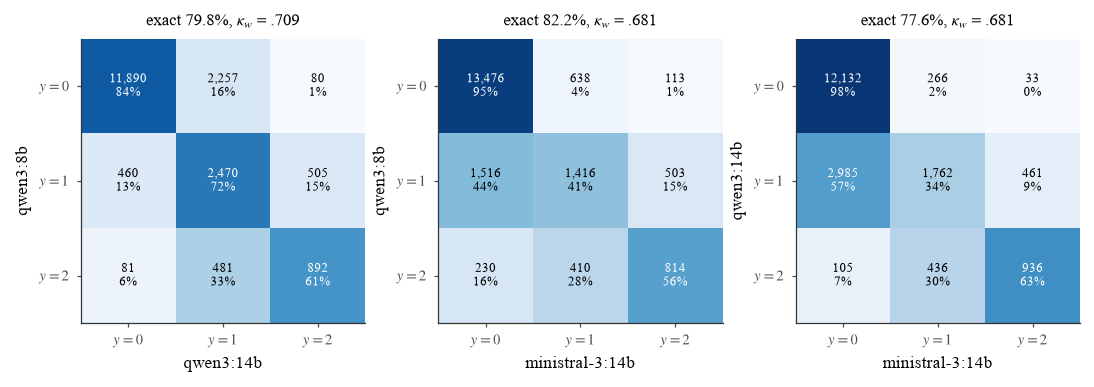

,exact agreement,κ_w (quadratic),κ (unweighted),up (%),down (%),0↔2 flips
pair,,,,,,
qwen3-8b→qwen3-14b,0.798,0.709,0.562,14.867,5.346,161
qwen3-8b→ministral-3-14b,0.822,0.681,0.529,6.560,11.279,343
qwen3-14b→ministral-3-14b,0.776,0.681,0.492,3.976,18.445,138


In [4]:
style()
agree_rows = []
fig, axes = plt.subplots(1, 3, figsize=figsize(2, 0.66))
for ax, (a, b) in zip(axes.ravel(), PAIRS):
    ya, yb = gt[a].grade.values, gt[b].grade.values
    cm = confusion_matrix(ya, yb, labels=GRADES)
    row_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=100)
    for i in GRADES:
        for k in GRADES:
            ax.text(k, i, f"{cm[i, k]:,}\n{row_pct[i, k]:.0f}%", ha="center", va="center", fontsize=6,
                    color="white" if row_pct[i, k] > 55 else "black")
    kw = cohen_kappa_score(ya, yb, weights="quadratic")
    ax.set_xticks(GRADES, labels=[f"$y={k}$" for k in GRADES])
    ax.set_yticks(GRADES, labels=[f"$y={k}$" for k in GRADES])
    ax.set_xlabel(JUDGES[b])
    ax.set_ylabel(JUDGES[a])
    ax.set_title(f"exact {np.mean(ya == yb):.1%}, " + rf"$\kappa_w$ = {f3(kw)}")
    agree_rows.append({"pair": f"{a}→{b}", "exact agreement": np.mean(ya == yb), "κ_w (quadratic)": kw,
                       "κ (unweighted)": cohen_kappa_score(ya, yb),
                       "up (%)": np.mean(yb > ya) * 100, "down (%)": np.mean(yb < ya) * 100,
                       "0↔2 flips": int(np.sum(np.abs(yb - ya) == 2))})
plt.savefig(IMG_DIR / "judge_agreement.pdf", transparent=True)
plt.show()
agree = pd.DataFrame(agree_rows).set_index("pair")
agree.round(3)


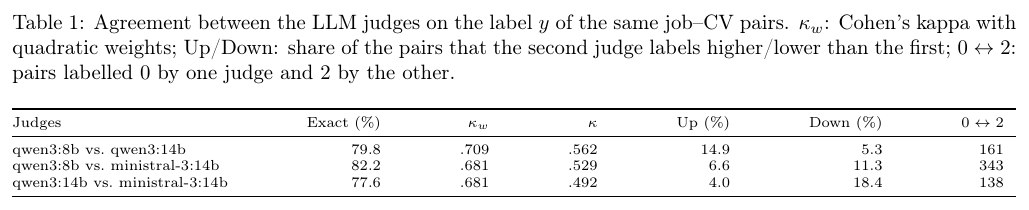

In [5]:
body = [" & ".join([rf"{JUDGES[a]} vs.\ {JUDGES[b]}", f"{100 * r['exact agreement']:.1f}",
                    f3(r["κ_w (quadratic)"]), f3(r["κ (unweighted)"]),
                    f"{r['up (%)']:.1f}", f"{r['down (%)']:.1f}", f"{int(r['0↔2 flips']):,}"]) + r" \\"
        for (a, b), (_, r) in zip(PAIRS, agree.iterrows())]
save_tex("judge_agreement", float_table(
    r"Agreement between the LLM judges on the label $y$ of the same job--CV pairs. "
    r"$\kappa_w$: Cohen's kappa with quadratic weights; Up/Down: share of the pairs that the second judge "
    r"labels higher/lower than the first; $0 \leftrightarrow 2$: pairs labelled $0$ by one judge and $2$ by the other.",
    "tab:judge-agreement", "l" + "r" * 6,
    [r"Judges & Exact (\%) & $\kappa_w$ & $\kappa$ & Up (\%) & Down (\%) & $0 \leftrightarrow 2$ \\"], body))


## 2. nDCG@10

*nDCG@10 per judge and KB and averaged, arm summary per judge and averaged, concordance of the
arm ordering across judges (paper: nDCG@10 comparison).*

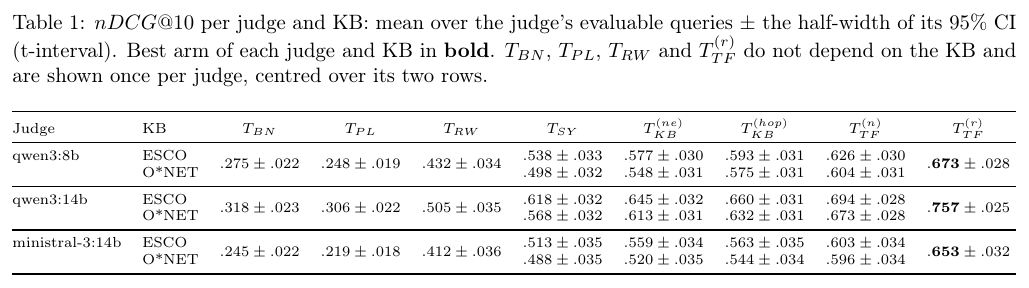

In [6]:
def ndcg_cell(r, best):
    m = f3(r.ndcg_mean)
    m = rf"\mathbf{{{m}}}" if best else m
    return rf"${m} \pm {f3(r.ndcg_ci_hi - r.ndcg_mean)}$"     # the t-interval is symmetric


FREE = [f for f in ARM_ORDER if f not in KB_METHODS]     # KB-free arms: the same value in both KB rows
mrow = lambda cell: rf"\multirow{{{len(KBS)}}}{{*}}{{{cell}}}"

body = []
for j in JUDGES:
    rows = {kb: S.loc[j].loc[kb_arms(kb)] for kb in KBS}
    best = {kb: rows[kb].ndcg_mean.idxmax() for kb in KBS}
    for i, kb in enumerate(KBS):
        cells = []
        for f in ARM_ORDER:
            a = arm_of(f, kb)
            if f not in FREE:
                cells.append(ndcg_cell(rows[kb].loc[a], a == best[kb]))
            elif i == 0:                                       # once, centred over the KB rows
                cells.append(mrow(ndcg_cell(rows[kb].loc[a], a in best.values())))
            else:
                cells.append("")                               # covered by the \multirow above
        body.append(" & ".join([JUDGES[j] if i == 0 else "", KB_TITLE[kb]] + cells) + r" \\")
    body.append(r"\midrule")
save_tex("ndcg_judges", float_table(
    r"$nDCG@10$ per judge and KB: mean over the judge's evaluable queries $\pm$ the half-width of its $95\%$ CI "
    r"(t-interval). Best arm of each judge and KB in \textbf{bold}. $\bn$, $\pl$, $\rw$ and $\tfr$ do not depend on the KB "
    r"and are shown once per judge, centred over its two rows.",
    "tab:ndcg-judges", "ll" + "c" * 8,
    ["Judge & KB & " + " & ".join(FAM_TEX[f] for f in ARM_ORDER) + r" \\"], body[:-1]
).replace(r"\centering\scriptsize", r"\centering\scriptsize\setlength{\tabcolsep}{3pt}", 1))

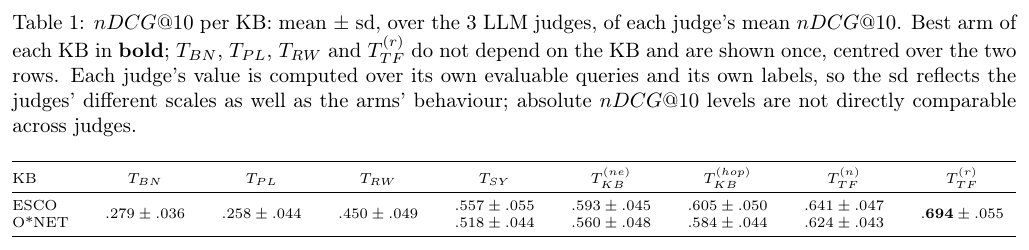

In [7]:
m = {a: summary.loc[summary.arm == a, "ndcg_mean"].values for a in FULL_ARMS}
best = {kb: max(kb_arms(kb), key=lambda a: m[a].mean()) for kb in KBS}
body = []
for i, kb in enumerate(KBS):
    cells = []
    for f in ARM_ORDER:
        a = arm_of(f, kb)
        if f not in FREE:
            cells.append(pm(m[a], a == best[kb]))
        elif i == 0:                                           # once, centred over the KB rows
            cells.append(mrow(pm(m[a], a in best.values())))
        else:
            cells.append("")                                   # covered by the \multirow above
    body.append(" & ".join([KB_TITLE[kb]] + cells) + r" \\")
save_tex("ndcg_avg", float_table(
    rf"$nDCG@10$ per KB: mean $\pm$ sd, over the {len(JUDGES)} LLM judges, of each judge's mean $nDCG@10$. "
    r"Best arm of each KB in \textbf{bold}; $\bn$, $\pl$, $\rw$ and $\tfr$ do not depend on the KB and are shown once, centred over the two rows. Each judge's value is computed over its own evaluable queries "
    r"and its own labels, so the sd reflects the judges' different scales as well as the arms' behaviour; "
    r"absolute $nDCG@10$ levels are not directly comparable across judges.",
    "tab:ndcg-avg", "l" + "c" * 8, ["KB & " + " & ".join(FAM_TEX[f] for f in ARM_ORDER) + r" \\"], body))

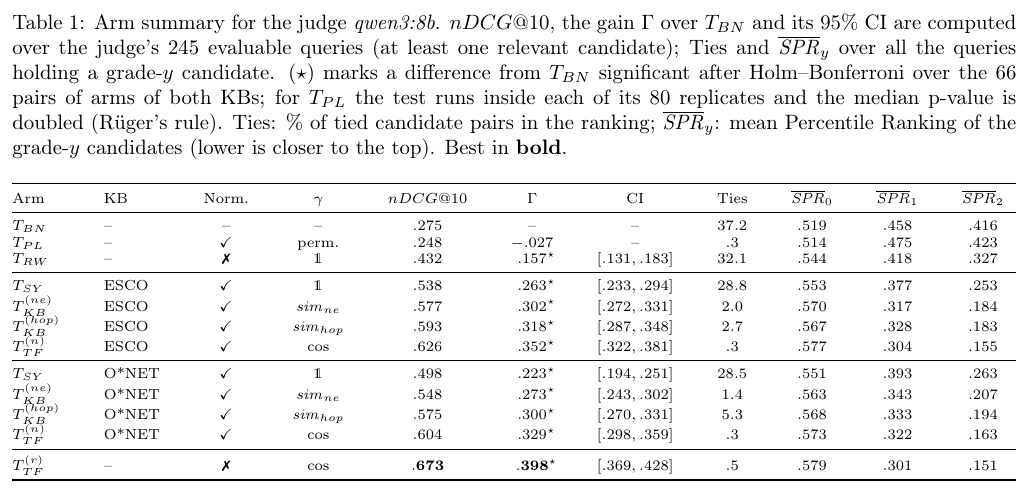

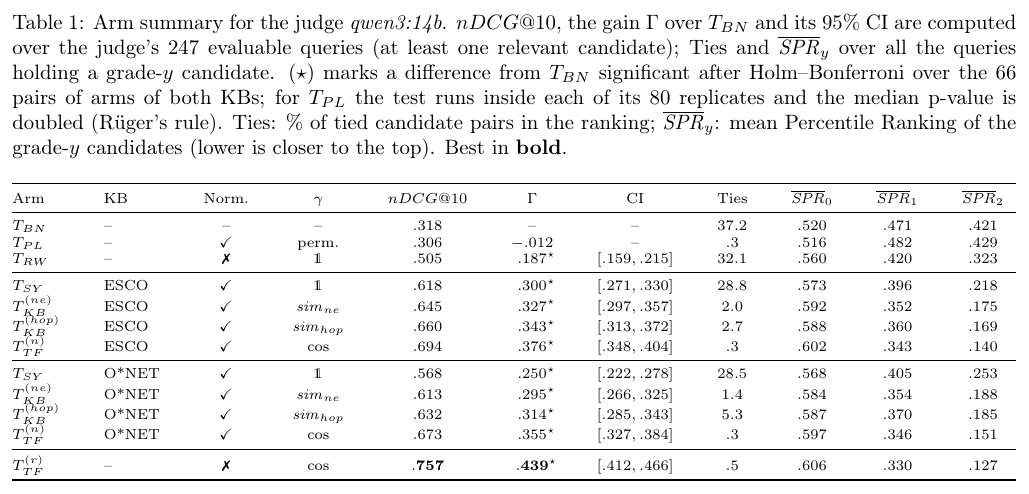

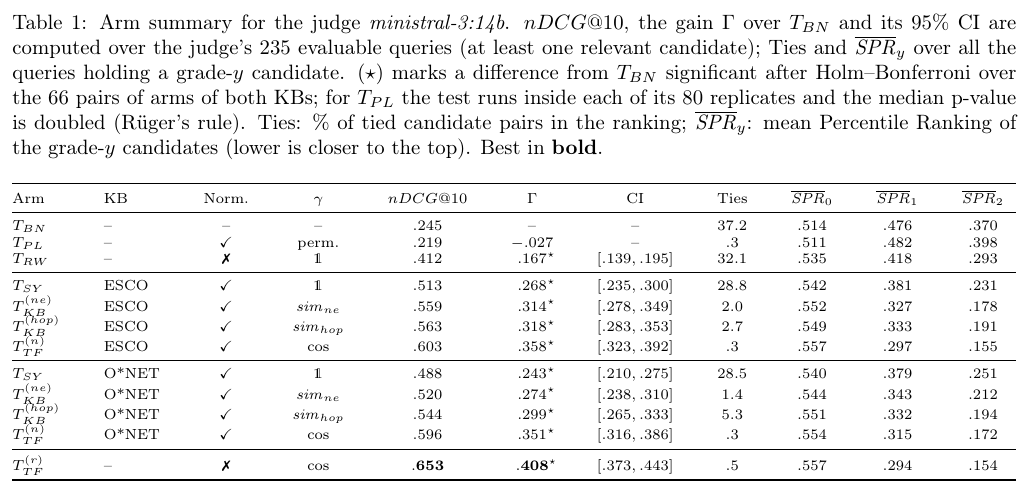

In [8]:
SPR_TEX = [rf"$\overline{{\mathit{{SPR}}}}_{g}$" for g in GRADES]


def blocks(cells):
    """The rows of a 12-arm table, one block of BLOCKS after the other, ruled apart."""
    out = []
    for block in BLOCKS:
        out += [" & ".join(cells[a]) + r" \\" for a in block] + [r"\midrule"]
    return out[:-1]


def front(a):
    """Arm, KB, Norm., gamma: the columns that describe the arm and not its numbers."""
    fam, kb = S.loc[(REF, a), ["family", "kb"]]
    return [FAM_TEX[fam], KB_TITLE.get(kb, "--"), *META[fam]]


def judge_cells(j):
    t = S.loc[j]
    best = t.ndcg_mean.idxmax()
    cells = {}
    for a, r in t.iterrows():
        bold = (lambda s: rf"\mathbf{{{s}}}") if a == best else (lambda s: s)
        gamma = "--" if a == BASELINE else f"${bold(f3(r.gamma))}$" + mark(r.p_vs_bn < ALPHA)
        ci = "--" if a in (BASELINE, "Placebo") else f"$[{f3(r.gamma_ci_lo)}, {f3(r.gamma_ci_hi)}]$"
        cells[a] = front(a) + [f"${bold(f3(r.ndcg_mean))}$", gamma, ci, f"${nz(f'{r.ties:.1f}')}$"] + [
            f"${f3(r[f'spr_{g}'])}$" for g in GRADES]
    return cells


HEAD_J = [" & ".join(["Arm", "KB", "Norm.", r"$\gamma$", r"$nDCG@10$", r"$\Gamma$", "CI", "Ties"] + SPR_TEX) + r" \\"]
for j in JUDGES:
    n = int(S.loc[(j, BASELINE), "n_queries"])
    save_tex(f"arm_summary_{j}", float_table(
        rf"Arm summary for the judge \textit{{{JUDGES[j]}}}. $nDCG@10$, the gain $\Gamma$ over $\bn$ and its "
        rf"$95\%$ CI are computed over the judge's ${n}$ evaluable queries (at least one relevant candidate); "
        r"Ties and $\overline{\mathit{SPR}}_y$ over all the queries holding a grade-$y$ candidate. $(\star)$ "
        rf"marks a difference from $\bn$ significant after Holm--Bonferroni over the ${n_pairs}$ pairs of arms "
        r"of both KBs; for $\pl$ the test runs inside each of its $80$ replicates and the median p-value is "
        r"doubled (R\"uger's rule). Ties: \% of tied candidate pairs in the ranking; "
        r"$\overline{\mathit{SPR}}_y$: mean Percentile Ranking of the grade-$y$ candidates (lower is closer to "
        r"the top). Best in \textbf{bold}.",
        f"tab:arm-summary-{j}", "ll" + "c" * 9, HEAD_J, blocks(judge_cells(j))))

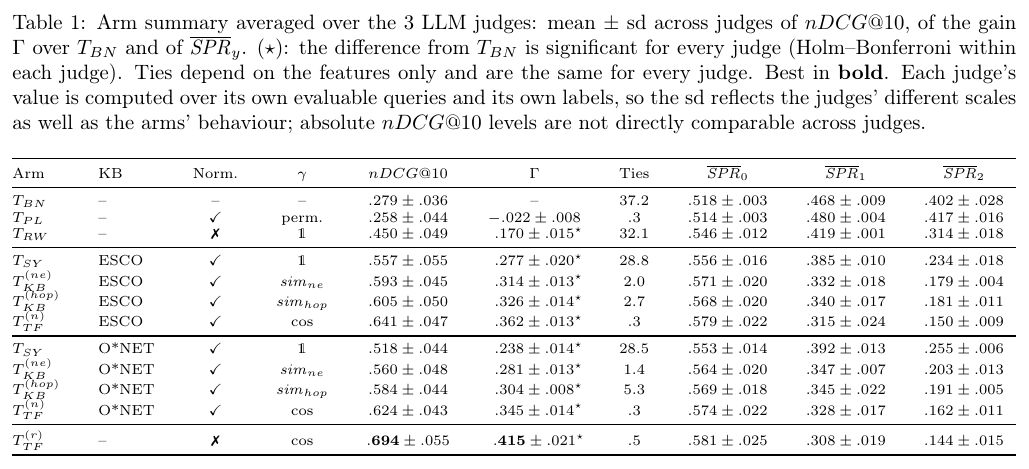

In [9]:
def avg_cells():
    best = max(FULL_ARMS, key=lambda a: summary.loc[summary.arm == a, "ndcg_mean"].mean())
    cells = {}
    for a in FULL_ARMS:
        r = summary[summary.arm == a]
        assert r.ties.nunique() == 1, f"{a}: ties depend only on the features and must match across judges"
        gamma = "--" if a == BASELINE else pm(r.gamma, a == best) + mark(bool((r.p_vs_bn < ALPHA).all()))
        cells[a] = front(a) + [pm(r.ndcg_mean, a == best), gamma, f"${nz(f'{r.ties.iloc[0]:.1f}')}$"] + [
            pm(r[f"spr_{g}"]) for g in GRADES]
    return cells


save_tex("arm_summary_avg", float_table(
    rf"Arm summary averaged over the {len(JUDGES)} LLM judges: mean $\pm$ sd across judges of $nDCG@10$, of the gain "
    r"$\Gamma$ over $\bn$ and of $\overline{\mathit{SPR}}_y$. $(\star)$: the difference from $\bn$ is significant for "
    r"every judge (Holm--Bonferroni within each judge). Ties depend on the features only and are the same for every "
    r"judge. Best in \textbf{bold}. Each judge's value is computed over its own evaluable queries and its own "
    r"labels, so the sd reflects the judges' different scales as well as the arms' behaviour; absolute "
    r"$nDCG@10$ levels are not directly comparable across judges.",
    "tab:arm-summary-avg", "ll" + "c" * 8,
    [" & ".join(["Arm", "KB", "Norm.", r"$\gamma$", r"$nDCG@10$", r"$\Gamma$", "Ties"] + SPR_TEX) + r" \\"],
    blocks(avg_cells())))

ESCO                              O*NET            \
                qwen3-8b qwen3-14b ministral-3-14b qwen3-8b qwen3-14b   
B_only                 7         7               7        7         7   
Placebo                8         8               8        8         8   
SY_raw                 6         6               6        6         6   
SY                     5         5               5        5         5   
KB_neighbor            4         4               4        4         4   
KB_hop                 3         3               3        3         3   
Transformer            2         2               2        2         2   
Transformer_raw        1         1               1        1         1   

                                 
                ministral-3-14b  
B_only                        7  
Placebo                       8  
SY_raw                        6  
SY                            5  
KB_neighbor                   4  
KB_hop                        3  
Transformer                   2  
Transformer_raw               1

,ESCO,O*NET
qwen3-8b→qwen3-14b,1.0,1.0
qwen3-8b→ministral-3-14b,1.0,1.0
qwen3-14b→ministral-3-14b,1.0,1.0


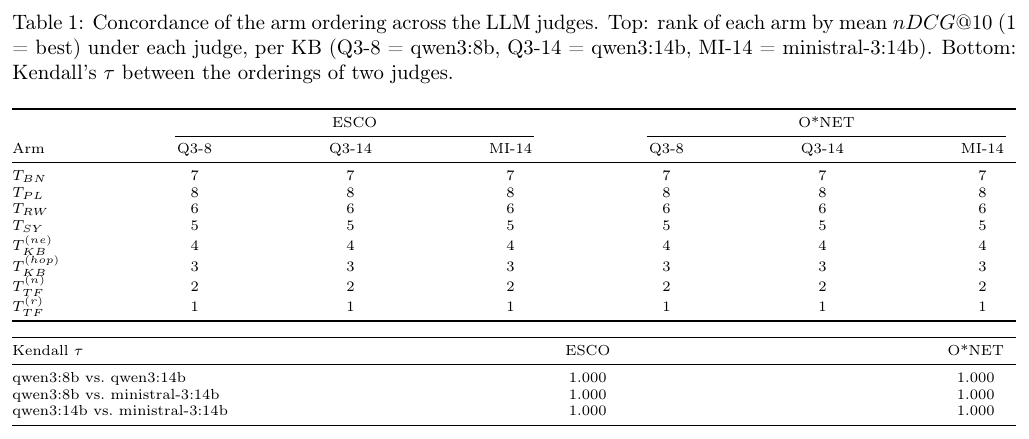

In [10]:
SHORT = {"qwen3-8b": "Q3-8", "qwen3-14b": "Q3-14", "ministral-3-14b": "MI-14"}
RANKS = {kb: pd.DataFrame({j: S.loc[j].loc[kb_arms(kb)].ndcg_mean.rank(ascending=False, method="min").astype(int)
                           for j in JUDGES}).set_axis(ARM_ORDER) for kb in KBS}
TAU = pd.DataFrame({KB_TITLE[kb]: [kendalltau(RANKS[kb][a], RANKS[kb][b]).statistic for a, b in PAIRS] for kb in KBS},
                   index=[f"{a}→{b}" for a, b in PAIRS])
display(pd.concat({KB_TITLE[kb]: RANKS[kb] for kb in KBS}, axis=1), TAU.round(3))

rank_body = [" & ".join([FAM_TEX[f]] + [str(RANKS[kb].loc[f, j]) for kb in KBS for j in JUDGES]) + r" \\"
             for f in ARM_ORDER]
tau_body = [" & ".join([rf"{JUDGES[a]} vs.\ {JUDGES[b]}"] + [nz(f"{t:.3f}") for t in TAU.loc[f"{a}→{b}"]]) + r" \\"
            for a, b in PAIRS]
n_j = len(JUDGES)                                  # a KB block spans one column per judge
legend = ", ".join(f"{SHORT[j]} = {JUDGES[j]}" for j in JUDGES)
save_tex("arm_conc_judges", "\n".join([
    r"\begin{table}", r"\centering\scriptsize",
    rf"\caption{{Concordance of the arm ordering across the LLM judges. Top: rank of each arm by mean $nDCG@10$ "
    rf"(1 = best) under each judge, per KB ({legend}). Bottom: Kendall's $\tau$ between the orderings of two judges.}}",
    r"\label{tab:arm-conc-judges}",
    r"\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}l" + "c" * (2 * n_j) + "}", r"\toprule",
    rf"& \multicolumn{{{n_j}}}{{c}}{{ESCO}} & \multicolumn{{{n_j}}}{{c}}{{O*NET}} \\",
    rf"\cmidrule(lr){{2-{1 + n_j}}}\cmidrule(lr){{{2 + n_j}-{1 + 2 * n_j}}}",
    "Arm & " + " & ".join([SHORT[j] for j in JUDGES] * 2) + r" \\", r"\midrule", *rank_body,
    r"\bottomrule", r"\end{tabular*}", r"\par\medskip",
    r"\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}lcc}", r"\toprule",
    r"Kendall $\tau$ & ESCO & O*NET \\", r"\midrule", *tau_body, r"\bottomrule", r"\end{tabular*}",
    r"\end{table}"]))

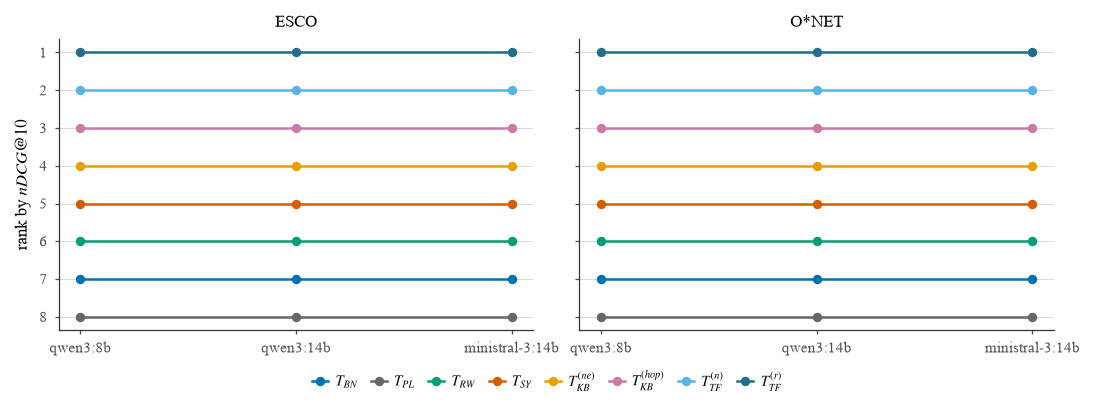

In [11]:
style()
fig, axes = plt.subplots(1, len(KBS), figsize=figsize(2, 0.36), sharey=True)
xs = np.arange(len(JUDGES))
for ax, kb in zip(axes, KBS):
    for f in ARM_ORDER:
        ax.plot(xs, RANKS[kb].loc[f].values, "-o", color=COLOR[f], lw=1.2, ms=3.5, label=LABEL[f], zorder=3)
    ax.set_xticks(xs, labels=list(JUDGES.values()))
    ax.set_yticks(range(1, len(ARM_ORDER) + 1))
    ax.set_title(KB_TITLE[kb])
    paper_ax(ax)
axes[0].invert_yaxis()                       # rank 1 on top; the y axis is shared
axes[0].set_ylabel(r"rank by $nDCG@10$")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=len(ARM_ORDER))
plt.savefig(IMG_DIR / "arm_conc_judges.pdf", transparent=True)
plt.show()

## 3. Rank Change

*Rank change per judge and KB, and averaged across judges (paper: Rank Change comparison).*

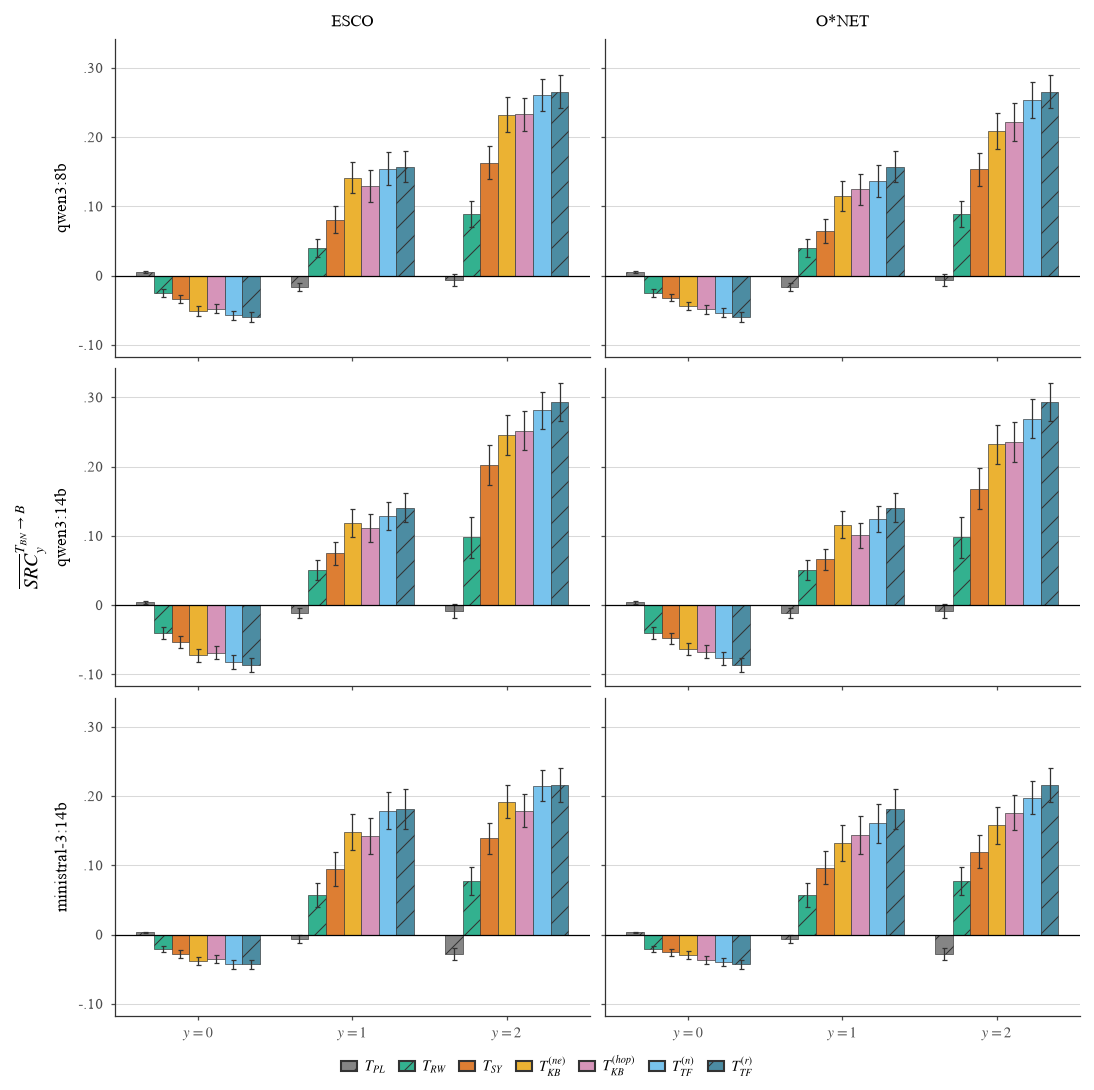

In [12]:
BARS = ARM_ORDER[1:]                                    # every arm but the baseline the gains are over
FLAT = ["Placebo", "SY_raw", "Transformer_raw"]         # KB-free: the same bars in both panels, hatched
SRC_LABEL = r"$\overline{\mathit{SRC}}^{T_{BN} \rightarrow B}_y$"


def bars_panel(ax, value, err):
    """One gain_comp panel: per grade, one bar per arm of BARS. value(f), err(f) -> 3 numbers."""
    w = 0.8 / len(BARS)
    for k, f in enumerate(BARS):
        ax.bar(GRADES + (k - (len(BARS) - 1) / 2) * w, value(f), w, yerr=err(f), capsize=1.2,
               color=solid(COLOR[f]), hatch="//" if f in FLAT else None, edgecolor="0.2", linewidth=0.3,
               zorder=3, error_kw=dict(lw=0.6, ecolor="0.2", capthick=0.6))
    ax.axhline(0, color="black", lw=0.6, zorder=4)
    ax.set_xticks(GRADES, labels=[f"$y={g}$" for g in GRADES])
    paper_ax(ax)


def bars_legend(fig):
    fig.legend([Patch(facecolor=solid(COLOR[f]), edgecolor="0.2", hatch="//" if f in FLAT else None) for f in BARS],
               [LABEL[f] for f in BARS], loc="outside lower center", ncol=len(BARS))


style()
plt.rcParams["hatch.linewidth"] = 0.5
fig, axes = plt.subplots(len(JUDGES), len(KBS), figsize=figsize(2, 1.0), sharex=True, sharey=True)
for r, j in enumerate(JUDGES):
    for c, kb in enumerate(KBS):
        cell = lambda f: SRC.loc[(j, arm_of(f, kb))].loc[GRADES]
        bars_panel(axes[r, c], lambda f: cell(f).src_mean.values,
                   lambda f: (cell(f).src_mean - cell(f).ci_lo).values)       # 95% CI over the queries
        axes[0, c].set_title(KB_TITLE[kb])
    axes[r, 0].set_ylabel(JUDGES[j])
trim_zero(axes[0, 0])
fig.supylabel(SRC_LABEL)
bars_legend(fig)
plt.savefig(IMG_DIR / "gain_comp_grid.pdf", transparent=True)
plt.show()

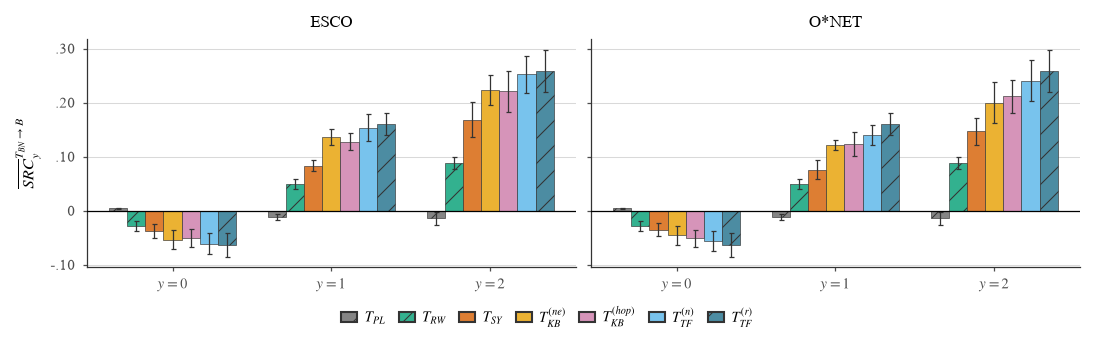

In [13]:
A = src.groupby(["arm", "grade"]).src_mean.agg(["mean", "std"])      # across the judges
style()
plt.rcParams["hatch.linewidth"] = 0.5
fig, axes = plt.subplots(1, len(KBS), figsize=figsize(2, 0.30), sharey=True)
for ax, kb in zip(axes, KBS):
    bars_panel(ax, lambda f: A.loc[arm_of(f, kb)].loc[GRADES, "mean"].values,
               lambda f: A.loc[arm_of(f, kb)].loc[GRADES, "std"].values)     # sd across the judges
    ax.set_title(KB_TITLE[kb])
axes[0].set_ylabel(SRC_LABEL)
trim_zero(axes[0])
bars_legend(fig)
plt.savefig(IMG_DIR / "gain_comp_avg.pdf", transparent=True)
plt.show()

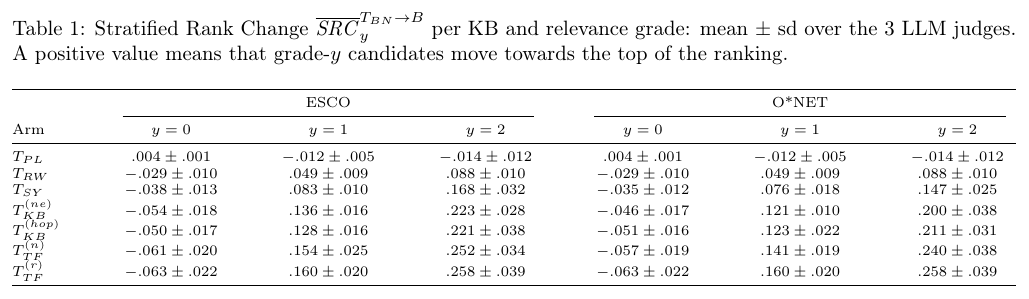

In [14]:
body = [" & ".join([FAM_TEX[f]] + [pm(src.loc[(src.arm == arm_of(f, kb)) & (src.grade == g), "src_mean"])
                                   for kb in KBS for g in GRADES]) + r" \\" for f in BARS]
save_tex("src_avg", float_table(
    rf"Stratified Rank Change $\overline{{\mathit{{SRC}}}}^{{\bn \rightarrow B}}_y$ per KB and relevance grade: "
    rf"mean $\pm$ sd over the {len(JUDGES)} LLM judges. A positive value means that grade-$y$ candidates move towards "
    r"the top of the ranking.",
    "tab:src-avg", "l" + "c" * 6,
    [r"& \multicolumn{3}{c}{ESCO} & \multicolumn{3}{c}{O*NET} \\", r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}",
     "Arm & " + " & ".join([f"$y={g}$" for g in GRADES] * 2) + r" \\"], body))